<a href="https://colab.research.google.com/github/MuhammadNihalImran/ML_Lab_Tasks/blob/main/ML_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib

Using matplotlib backend: <object object at 0x782d8daef000>



#Task 1: Load Dataset


In [ ]:
from sklearn.datasets import load_iris
data = load_iris()

In [ ]:
df = pd.DataFrame(data.data,columns=data.feature_names)

In [ ]:
df['target'] = data.target

#Task 2: Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.shape

(150, 5)

In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


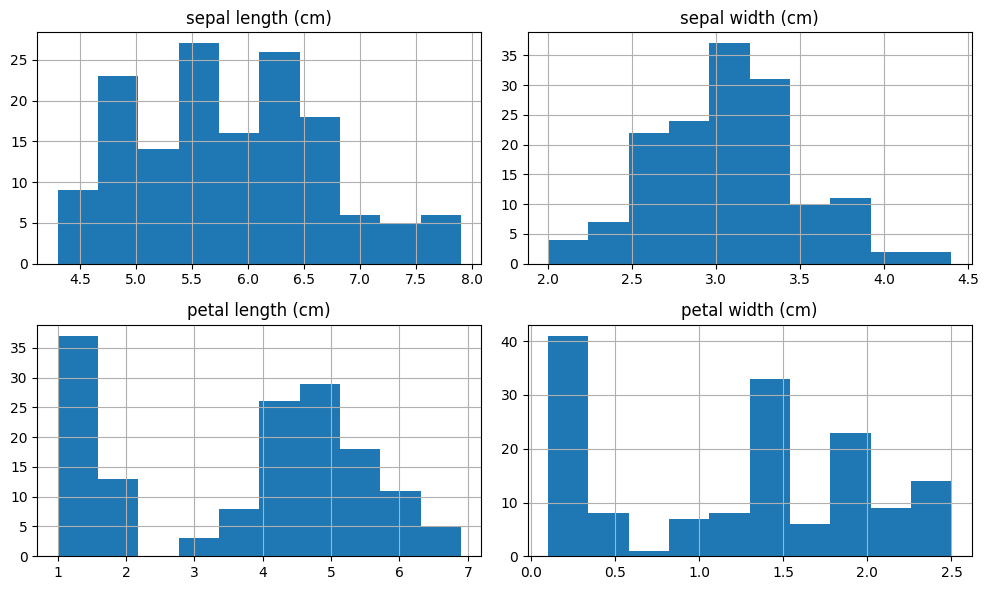

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

df.drop('target', axis=1).hist(figsize=(10, 6))

plt.tight_layout()
plt.show()

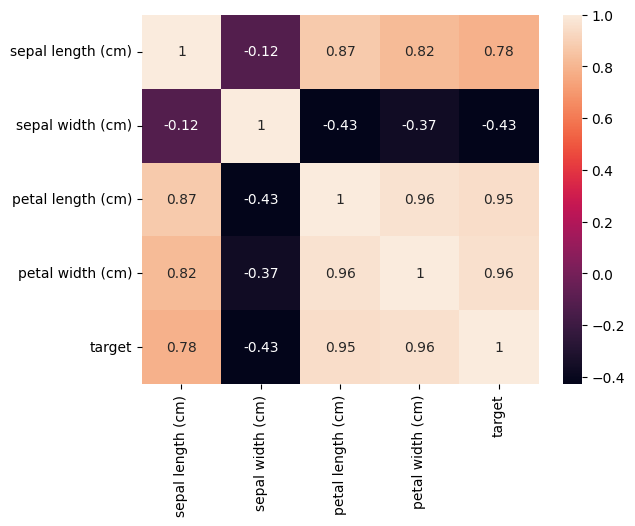

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()


#Task 3: Data Preprocessing


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

#Task 4: Build Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_test_pred = dtc.predict(X_test)
y_train_pred = dtc.predict(X_train)

#Task 5: Model Evaluation

In [ ]:
y_pred = dtc.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score on test:", accuracy_score(y_test, y_test_pred))
print("Accuracy Score on train:",accuracy_score(y_train, y_train_pred))


Accuracy Score on test: 1.0
Accuracy Score on train: 1.0


In [ ]:
print("Confusion Matrix on test:")
print(confusion_matrix(y_test, y_test_pred))

Confusion Matrix on test:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [ ]:
print("Classification Report on test:")
print(classification_report(y_test, y_test_pred))

Classification Report on test:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



#Task 6: Experimentation

In [ ]:
dfc_gini = DecisionTreeClassifier(criterion='gini',max_depth=3,min_samples_split=3)
dfc_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=3)

In [ ]:
y_test_pred_gini = dfc_gini.predict(X_test)
y_train_pred_gini = dfc_gini.predict(X_train)

In [ ]:
print("Gini Training Accuracy:",
      accuracy_score(y_train, y_train_pred_gini))

print("Gini Testing Accuracy:",
      accuracy_score(y_test, y_test_pred_gini))


Gini Training Accuracy: 0.9523809523809523
Gini Testing Accuracy: 1.0


In [ ]:
dfc_entro = DecisionTreeClassifier(criterion='entropy',max_depth=3,min_samples_split=3)
dfc_entro.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_split=3)

In [ ]:
y_test_pred_entro = dfc_entro.predict(X_test)
y_train_pred_entro = dfc_entro.predict(X_train)

In [ ]:
print("Entropy Training Accuracy:",
      accuracy_score(y_train, y_train_pred_entro))

print("Entropy Testing Accuracy:",
      accuracy_score(y_test, y_test_pred_entro))

Entropy Training Accuracy: 0.9619047619047619
Entropy Testing Accuracy: 1.0
